In [ ]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("git clone https://github.com/thezettascale/fp-emulation.git 2>/dev/null")
    sys.path.insert(0, "/content/fp-emulation/src")
else:
    # local: assume running from repo root or notebooks/
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

# FP64-Accurate Matmul via INT8 Tensor Cores

FP64 precision using INT8 MAC. Ozaki Scheme II: scale to integers, L modular matmuls via small primes, CRT reconstruction.

In [2]:
import torch
import time
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 1. Accuracy vs native FP64

n=   8  max_err=9.99e-16  rel_err=1.73e-14
n=  16  max_err=4.44e-15  rel_err=3.99e-14
n=  32  max_err=8.88e-15  rel_err=1.90e-12
n=  64  max_err=1.42e-14  rel_err=8.19e-13
n= 128  max_err=2.13e-14  rel_err=9.45e-12
n= 256  max_err=4.26e-14  rel_err=9.79e-12
n= 512  max_err=1.07e-13  rel_err=3.70e-11


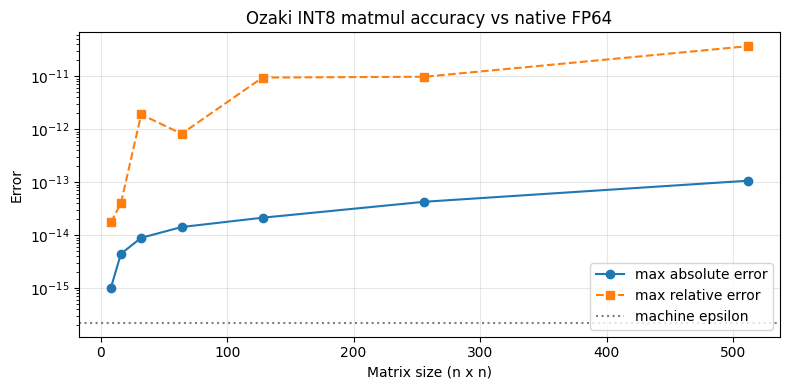

In [3]:
from fp_emulation import ozaki2_int8_matmul
from pathlib import Path
import os

# save figures to repo root, not cwd
fig_dir = Path("figures")
if not Path("src").exists():
    fig_dir = Path("..") / "figures"
fig_dir.mkdir(exist_ok=True)

sizes = [8, 16, 32, 64, 128, 256, 512]
max_errors = []
rel_errors = []

for n in sizes:
    A = torch.randn(n, n, dtype=torch.float64, device=device)
    B = torch.randn(n, n, dtype=torch.float64, device=device)
    torch.manual_seed(42)
    ref = A @ B
    ozaki = ozaki2_int8_matmul(A, B)
    max_err = torch.max(torch.abs(ozaki - ref)).item()
    rel_err = (torch.abs(ozaki - ref) / torch.abs(ref).clamp(min=1e-300)).max().item()
    max_errors.append(max_err)
    rel_errors.append(rel_err)
    print(f"n={n:4d}  max_err={max_err:.2e}  rel_err={rel_err:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(sizes, max_errors, "o-", label="max absolute error")
ax.semilogy(sizes, rel_errors, "s--", label="max relative error")
ax.axhline(2.2e-16, color="gray", ls=":", label="machine epsilon")
ax.set_xlabel("Matrix size (n x n)")
ax.set_ylabel("Error")
ax.set_title("Ozaki INT8 matmul accuracy vs native FP64")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir / "accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Latency: Ozaki INT8 vs native FP64

Ozaki does L modular matmuls + CRT reconstruction, so kernel launch overhead dominates at small n. At large n, INT8 tensor core throughput wins (T4: 130 TOPS INT8 vs 0.25 TFLOPS FP64).

n=  32  FP64=0.132ms  Ozaki=3.256ms  24.7x
n=  64  FP64=0.246ms  Ozaki=3.231ms  13.2x
n= 128  FP64=0.252ms  Ozaki=2.926ms  11.6x
n= 256  FP64=0.311ms  Ozaki=3.183ms  10.2x
n= 512  FP64=2.254ms  Ozaki=4.365ms  1.9x
n=1024  FP64=10.548ms  Ozaki=15.335ms  1.5x
n=2048  FP64=68.563ms  Ozaki=67.383ms  1.0x
n=4096  FP64=544.882ms  Ozaki=353.998ms  0.6x


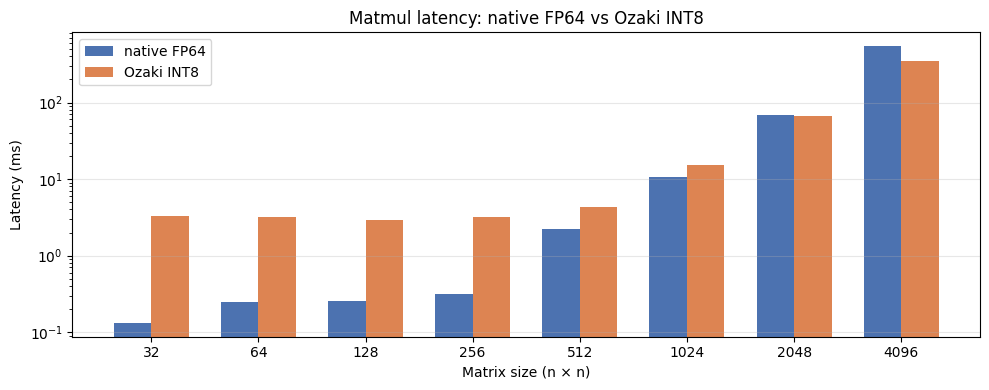

In [4]:
bench_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096]
n_warmup, n_iter = 5, 20

fp64_times, ozaki_times = [], []

for n in bench_sizes:
    A = torch.randn(n, n, dtype=torch.float64, device=device)
    B = torch.randn(n, n, dtype=torch.float64, device=device)

    for _ in range(n_warmup):
        _ = A @ B
        _ = ozaki2_int8_matmul(A, B)
    if device == "cuda":
        torch.cuda.synchronize()

    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    for _ in range(n_iter):
        _ = A @ B

    if device == "cuda":
        torch.cuda.synchronize()

    fp64_t = (time.perf_counter() - t0) / n_iter * 1000

    if device == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(n_iter):
        _ = ozaki2_int8_matmul(A, B)

    if device == "cuda":
        torch.cuda.synchronize()

    ozaki_t = (time.perf_counter() - t0) / n_iter * 1000

    fp64_times.append(fp64_t)
    ozaki_times.append(ozaki_t)
    ratio = ozaki_t / fp64_t
    print(f"n={n:4d}  FP64={fp64_t:.3f}ms  Ozaki={ozaki_t:.3f}ms  {ratio:.1f}x")

x = np.arange(len(bench_sizes))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w / 2, fp64_times, w, label="native FP64", color="#4c72b0")
ax.bar(x + w / 2, ozaki_times, w, label="Ozaki INT8", color="#dd8452")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in bench_sizes])
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Latency (ms)")
ax.set_yscale("log")
ax.set_title("Matmul latency: native FP64 vs Ozaki INT8")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(fig_dir / "benchmark.png", dpi=150, bbox_inches="tight")
plt.show()